#Credit Card Fault Detection

###Importation of packages

In [11]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

###Dataset's Loading

In [ ]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

 65%|██████▌   | 43.0M/66.0M [02:00<00:55, 436kB/s]

###Explorative Data Analysis

In [10]:
root = pathlib.Path().resolve()    
data = pd.read_csv(root.parents[0] / "data" / "raw" / "creditcard.csv")
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [12]:
data.shape

(284807, 31)

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [14]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [15]:
data.var()

Time      2.255124e+09
V1        3.836489e+00
V2        2.726820e+00
V3        2.299029e+00
V4        2.004684e+00
V5        1.905081e+00
V6        1.774946e+00
V7        1.530401e+00
V8        1.426479e+00
V9        1.206992e+00
V10       1.185594e+00
V11       1.041855e+00
V12       9.984034e-01
V13       9.905708e-01
V14       9.189055e-01
V15       8.378034e-01
V16       7.678191e-01
V17       7.213734e-01
V18       7.025394e-01
V19       6.626619e-01
V20       5.943254e-01
V21       5.395255e-01
V22       5.266428e-01
V23       3.899507e-01
V24       3.668084e-01
V25       2.717308e-01
V26       2.325429e-01
V27       1.629192e-01
V28       1.089550e-01
Amount    6.256007e+04
Class     1.724507e-03
dtype: float64

In [16]:
#Check duplicates lines
data.duplicated().sum()

np.int64(1081)

In [17]:
#Check missing values
data.isna().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Text(0.5, 1.0, 'correlation_matrix')

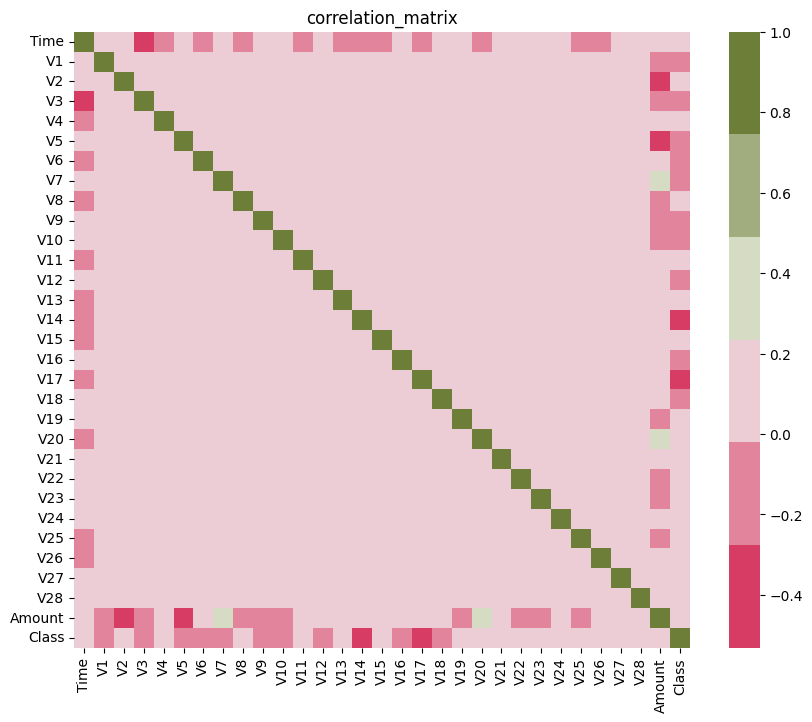

In [20]:
#Correlation's Matrix
f, ax = plt.subplots(figsize=(10, 8))
corr = data.corr()
sns.heatmap(corr,mask = np.zeros_like(corr,dtype = np.bool),cmap = sns.diverging_palette(2,100),square = True, ax=ax)

# ensure output directory exists and build full path
output_dir = root.parents[0] / "figures"
output_dir.mkdir(exist_ok=True, parents=True)
output_path = output_dir / "correlation_matrix.jpg"
plt.savefig(output_path)

plt.title('correlation_matrix')

In [ ]:
#Features correlation with the target
# select only the correlations with the target variable ("Class")
corr_series = corr['Class']
# (optional) drop the target itself so we don't plot a perfect 1.0 correlation
corr_series = corr_series.drop(labels='Class', errors='ignore')

plt.figure(figsize=(12, 8))
abs_corr_series = corr_series.abs().sort_values(ascending=False)
sns.barplot(x=abs_corr_series.index, y=abs_corr_series.values, hue=abs_corr_series.index, palette='viridis', legend=False)
plt.xticks(rotation=90) # Rotate feature names for better readability
plt.title('Absolute Feature Correlation with Target Class')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation with Class')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# save to figures directory with full path
output_dir = root.parents[0] / "figures"
output_dir.mkdir(exist_ok=True, parents=True)
output_path = output_dir / "features_correlation.jpg"
plt.savefig(output_path)

plt.show()

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

<Figure size 1200x800 with 0 Axes>

### Outiliers Visualization

A common way to visualize outliers for numerical features is by using **box plots**. A box plot displays the distribution of a dataset based on a five-number summary: minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum. Outliers are typically shown as individual points beyond the 'whiskers' of the box plot, which extend to 1.5 times the Interquartile Range (IQR) from Q1 and Q3.

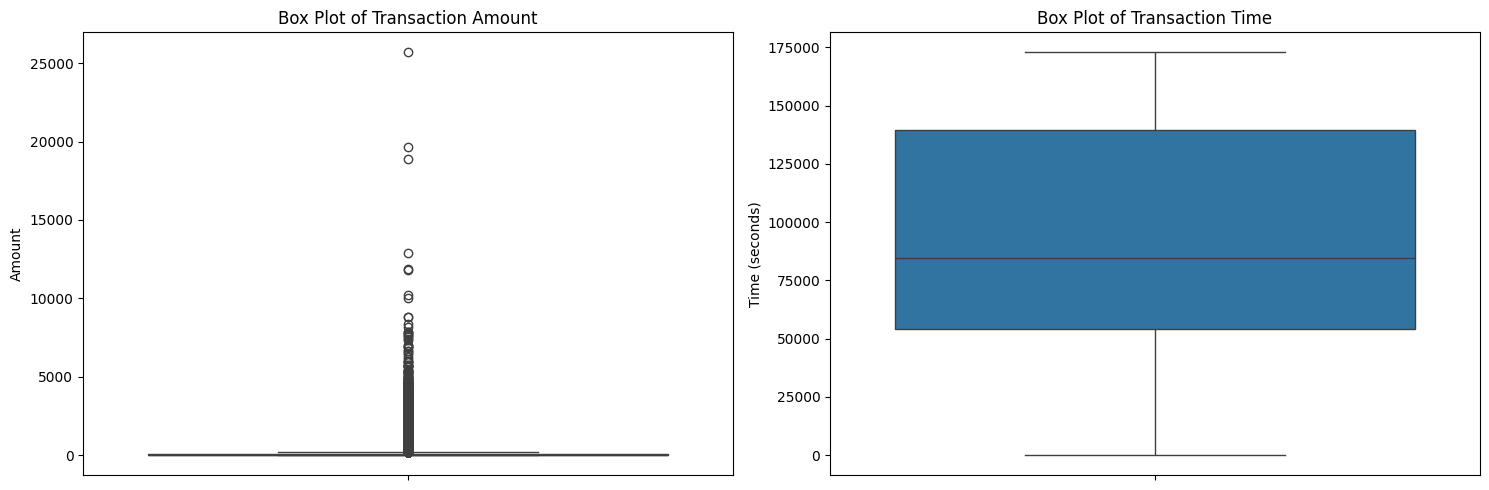

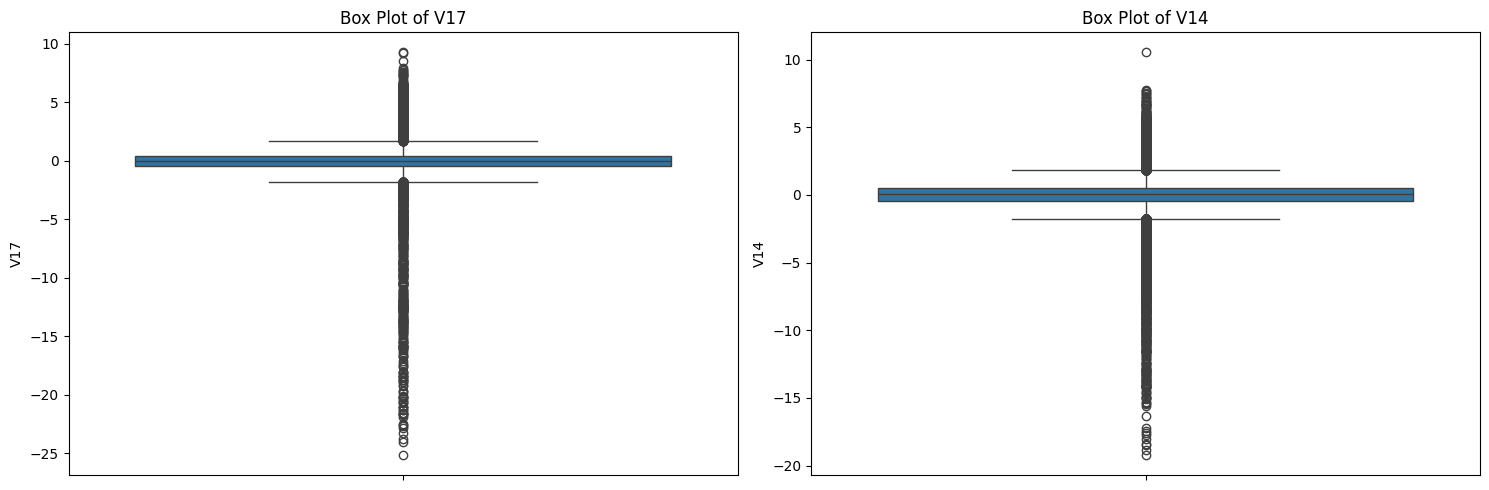

In [23]:
plt.figure(figsize=(15, 5))

# Box plot for 'Amount'
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=data['Amount'])
plt.title('Box Plot of Transaction Amount')
plt.ylabel('Amount')

# Box plot for 'Time'
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=data['Time'])
plt.title('Box Plot of Transaction Time')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

# Let's also look at some V-features, for example, V17 and V14 (highly correlated with Class)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.boxplot(y=data['V17'])
plt.title('Box Plot of V17')
plt.ylabel('V17')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=data['V14'])
plt.title('Box Plot of V14')
plt.ylabel('V14')

plt.tight_layout()
plt.show()

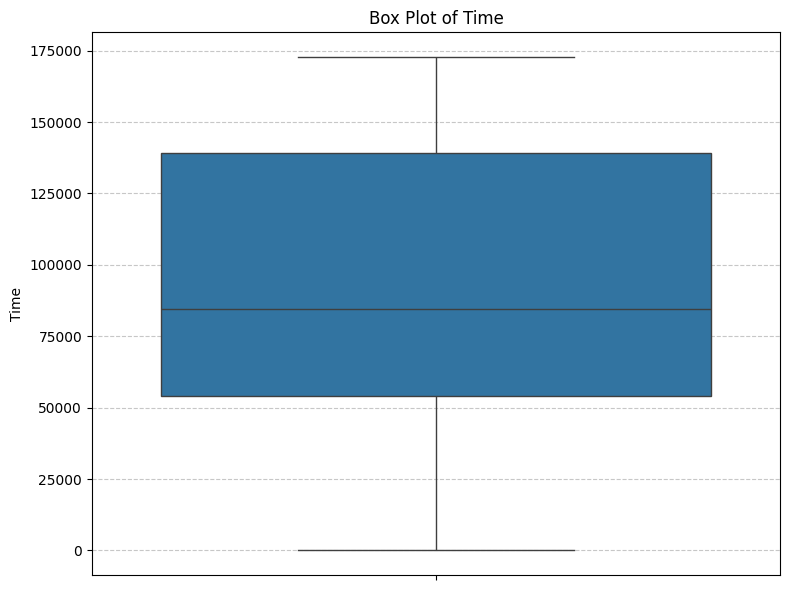

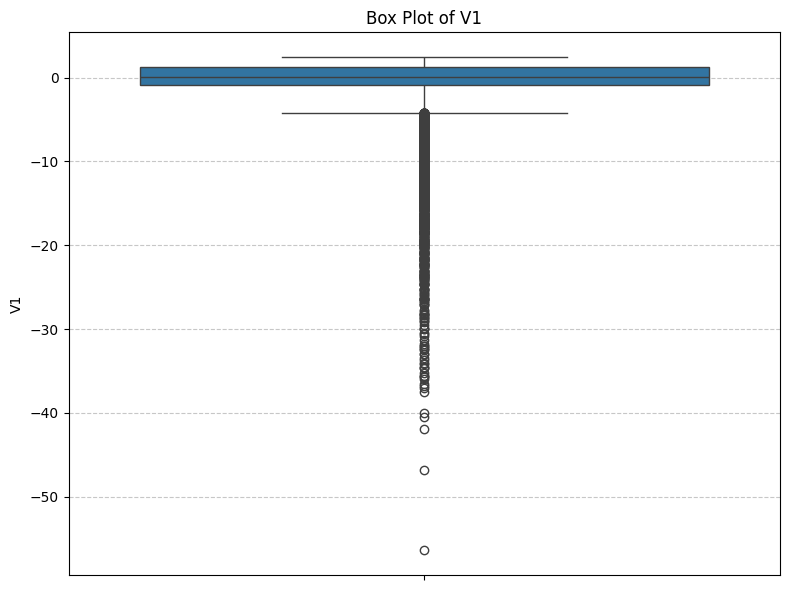

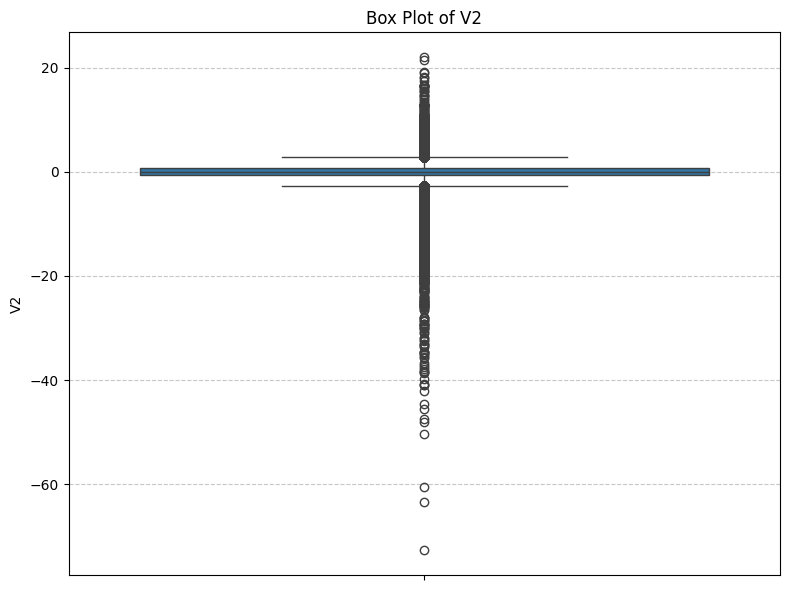

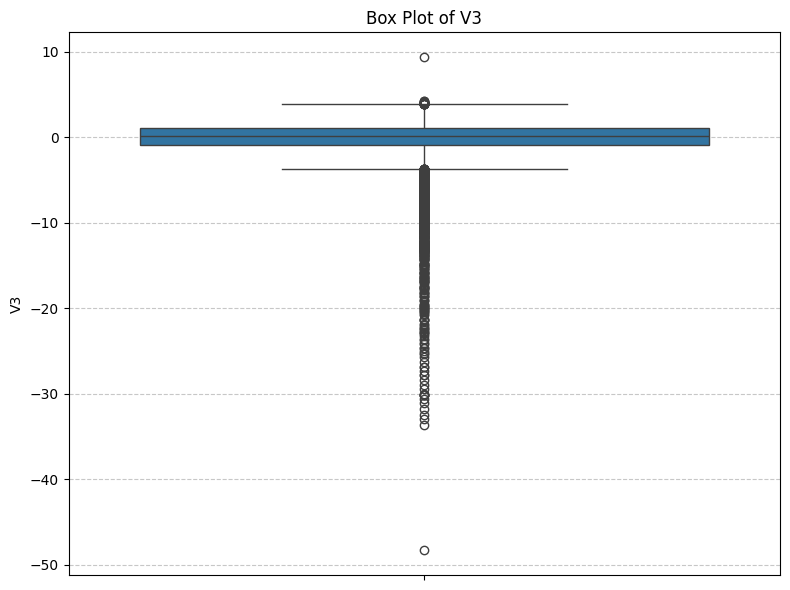

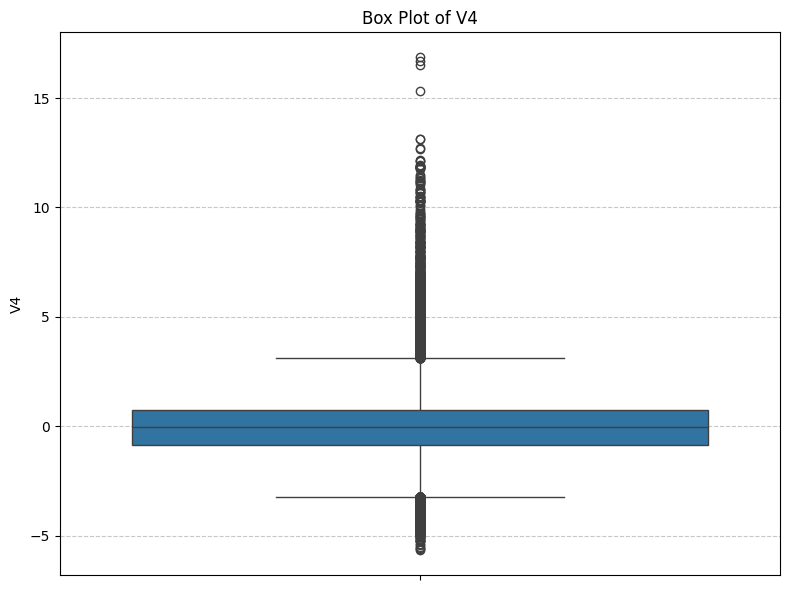

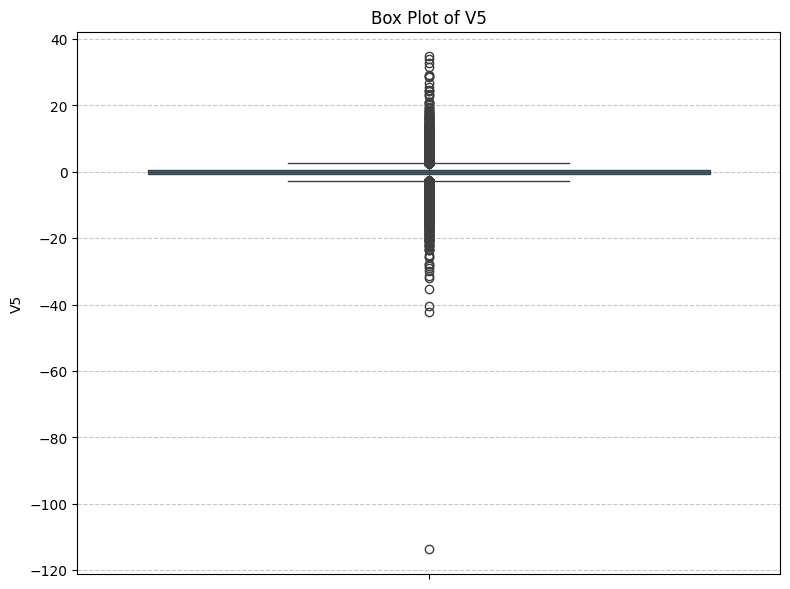

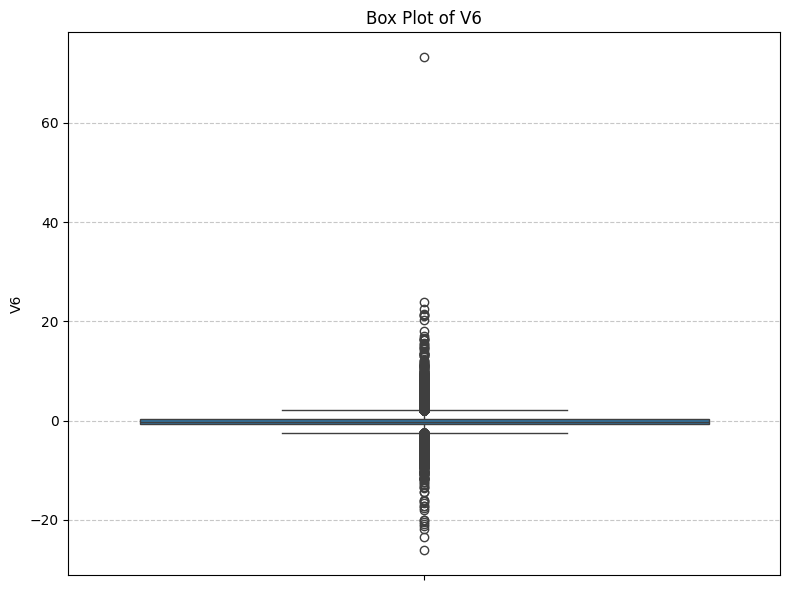

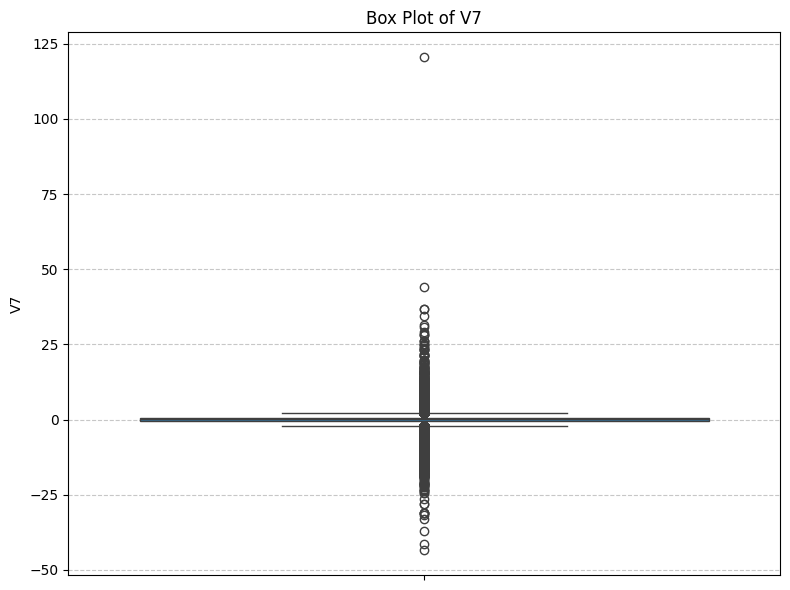

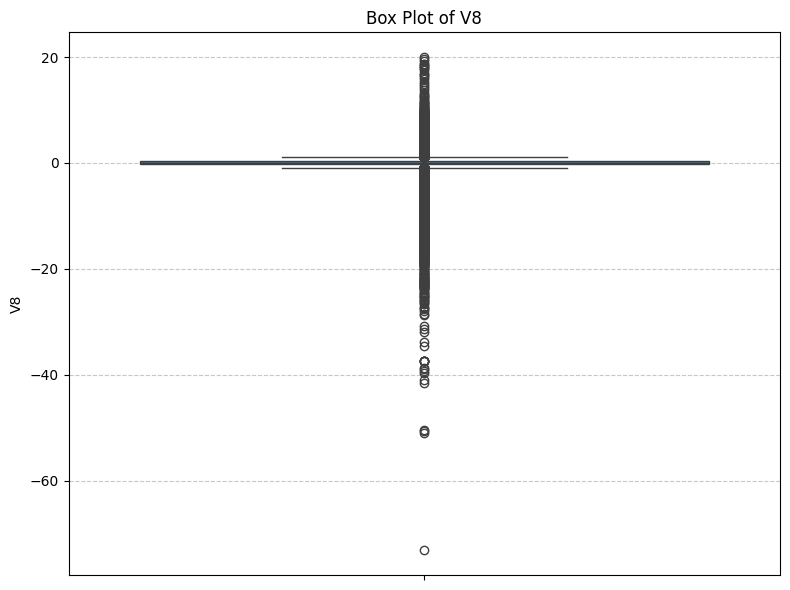

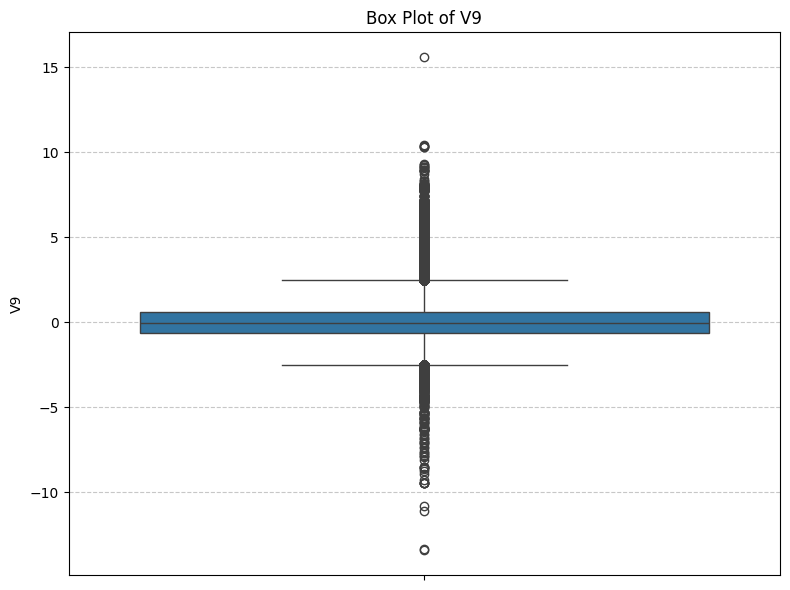

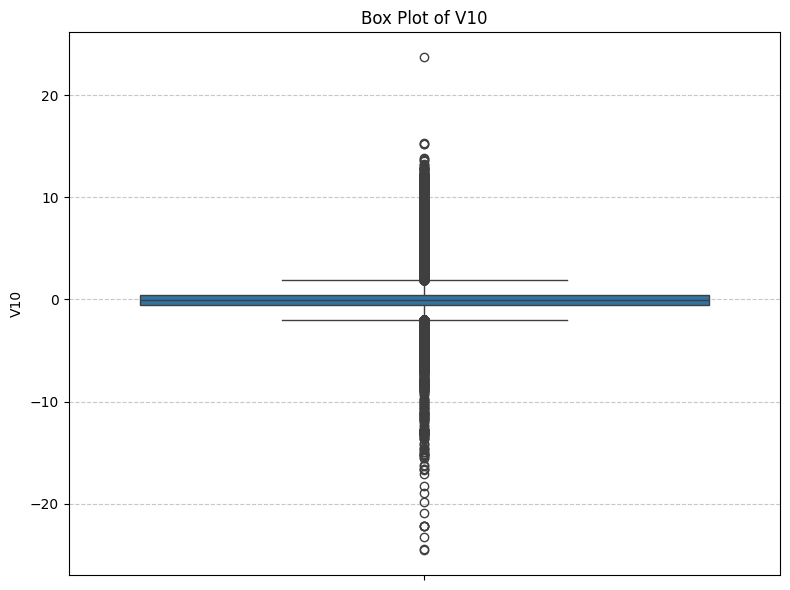

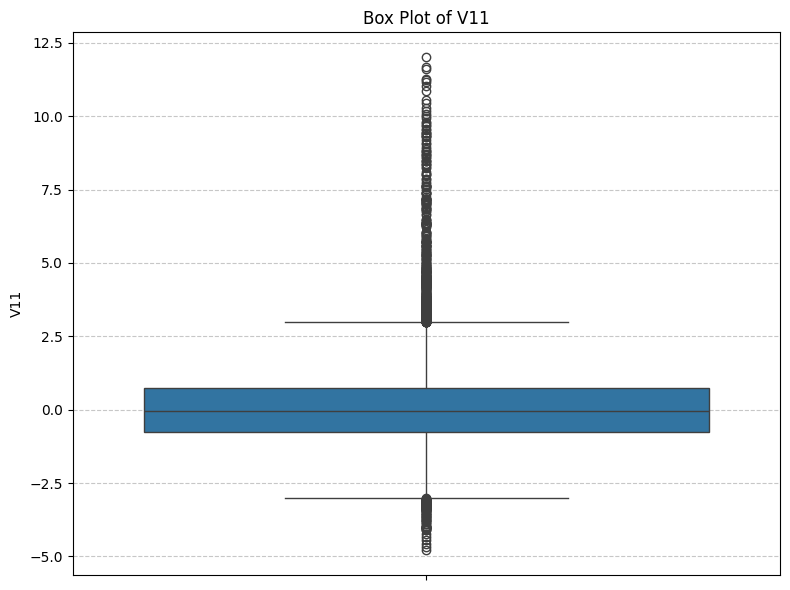

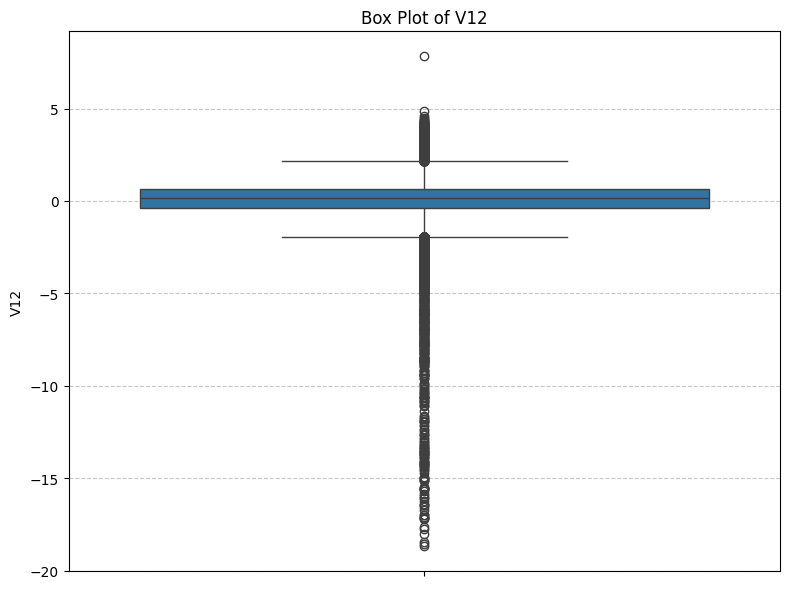

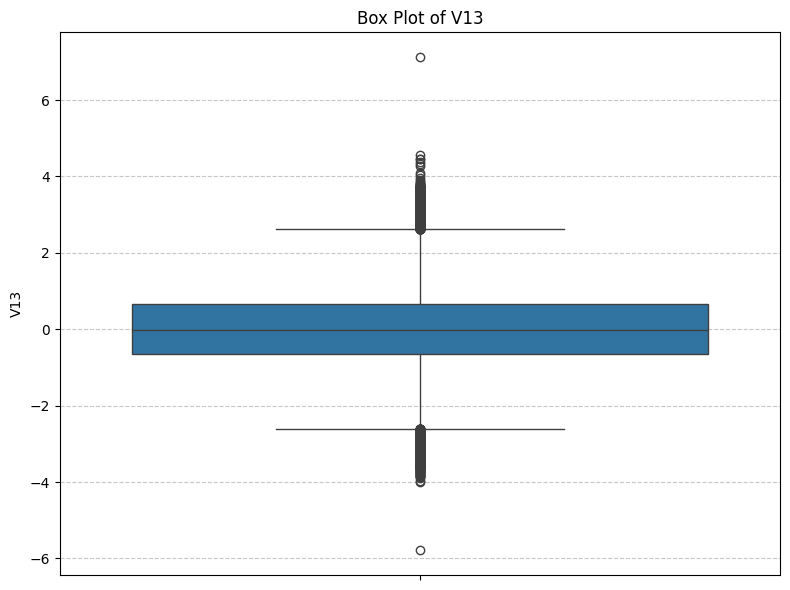

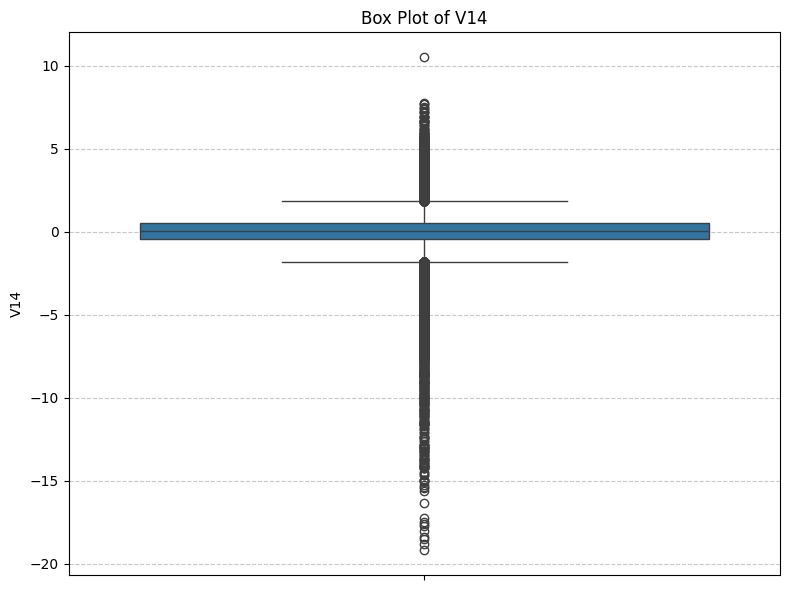

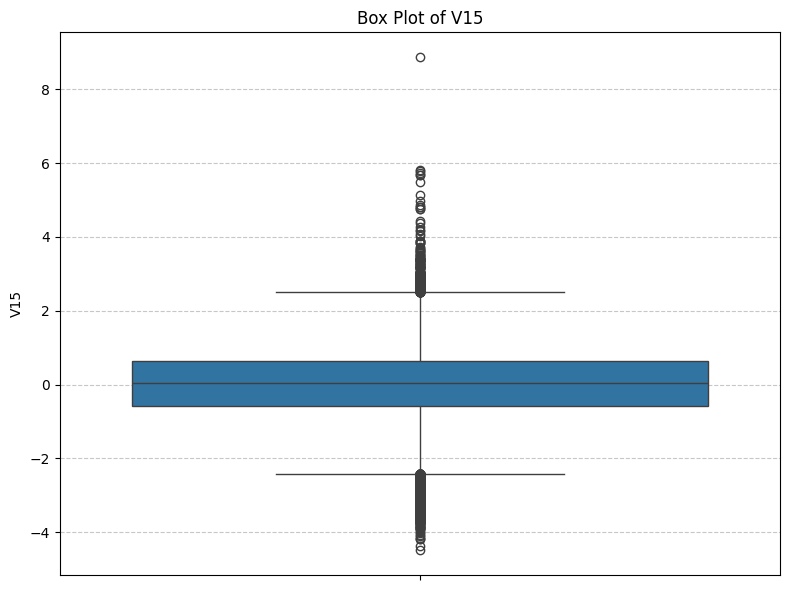

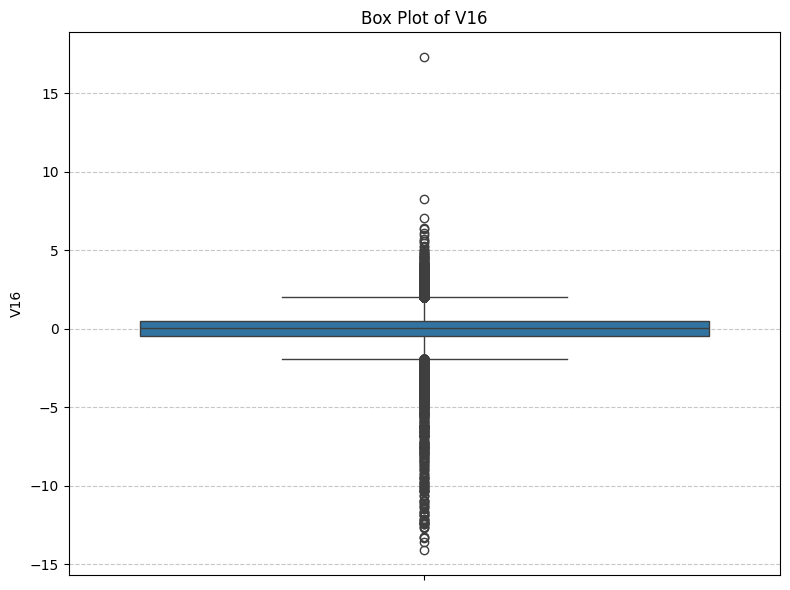

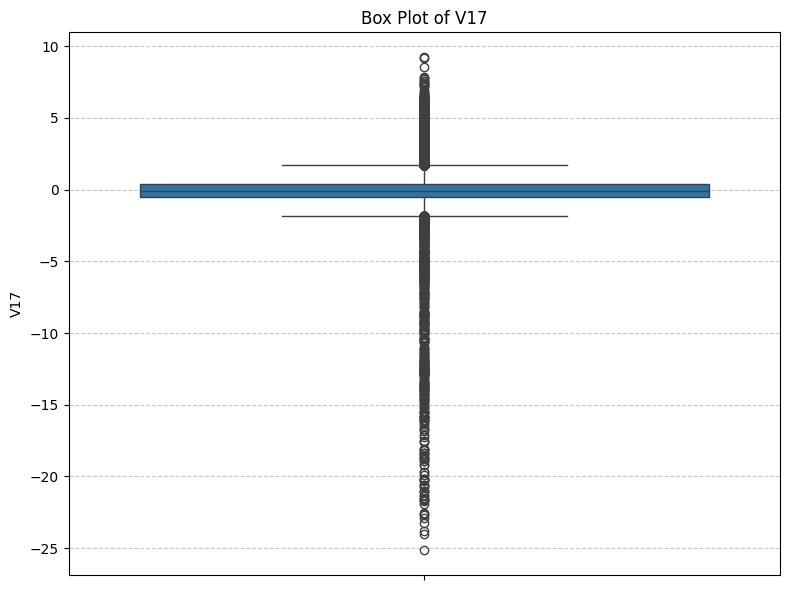

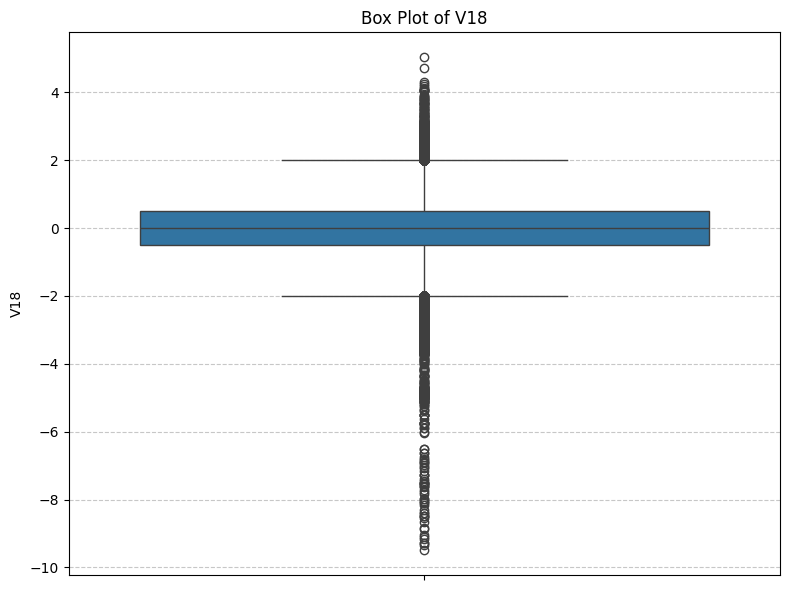

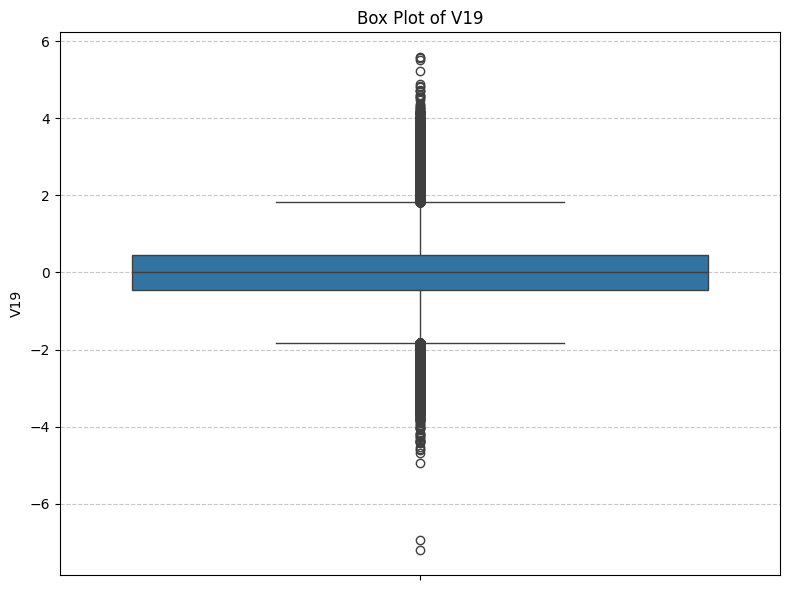

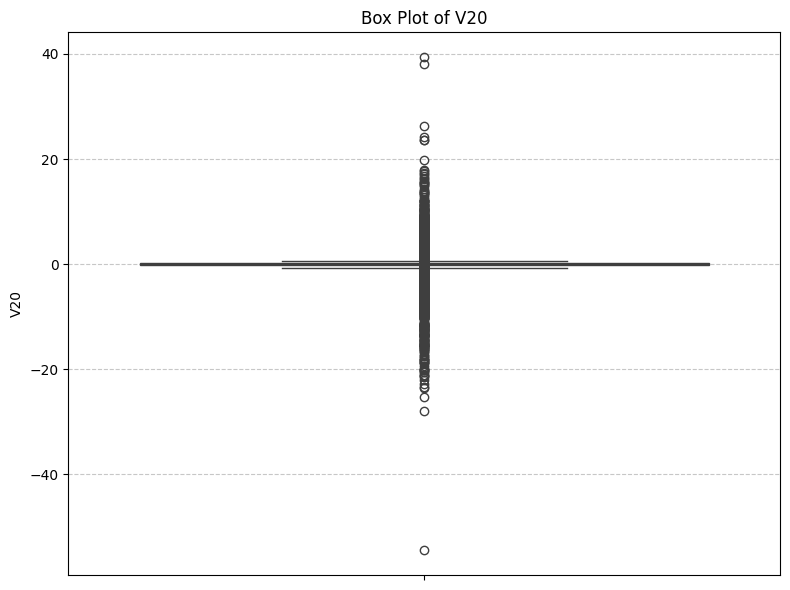

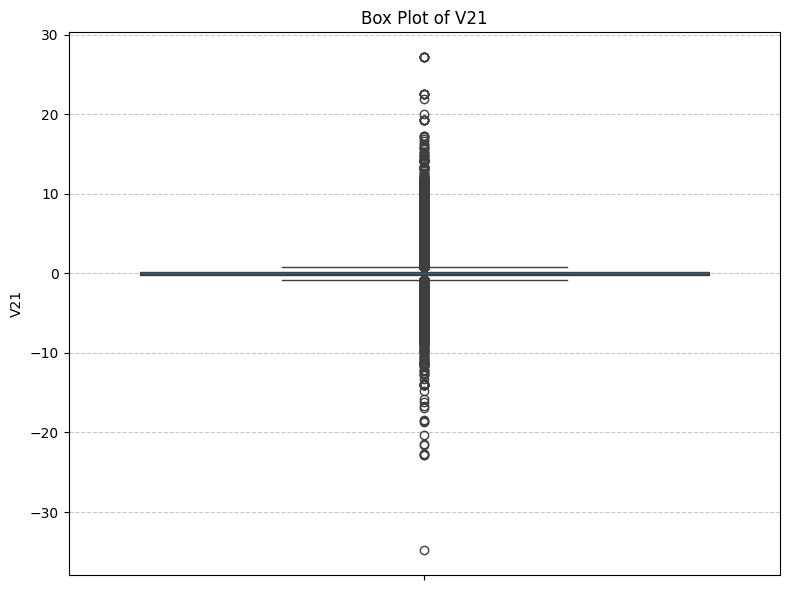

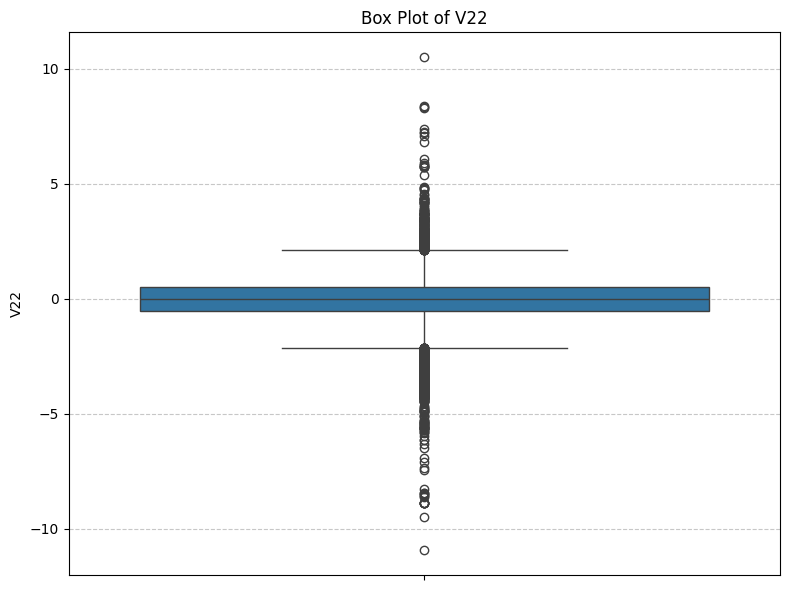

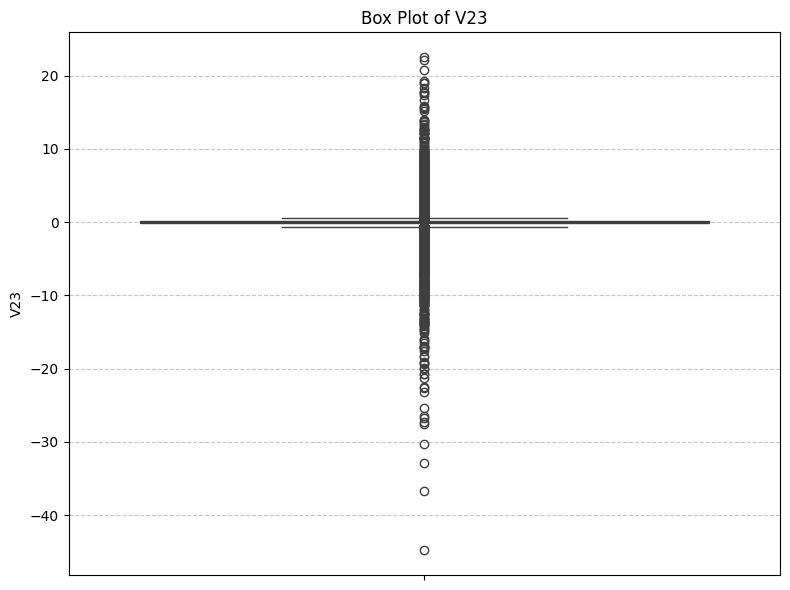

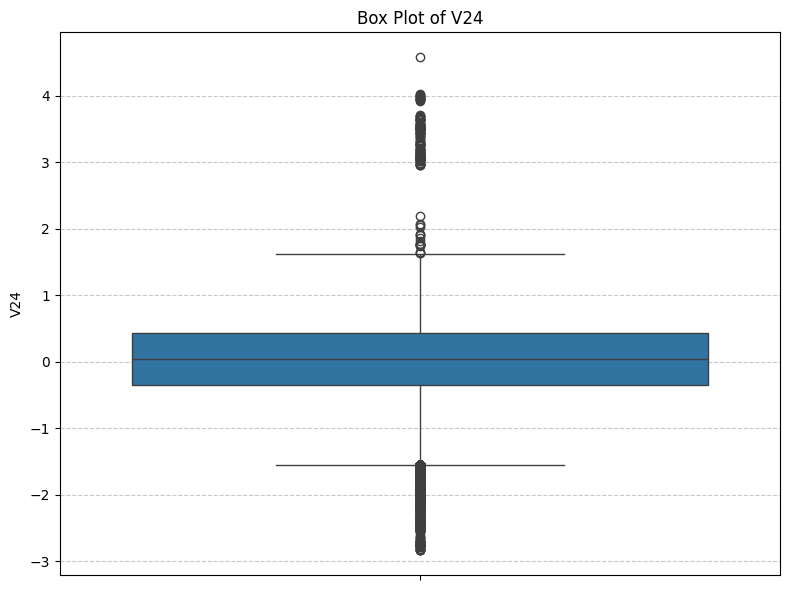

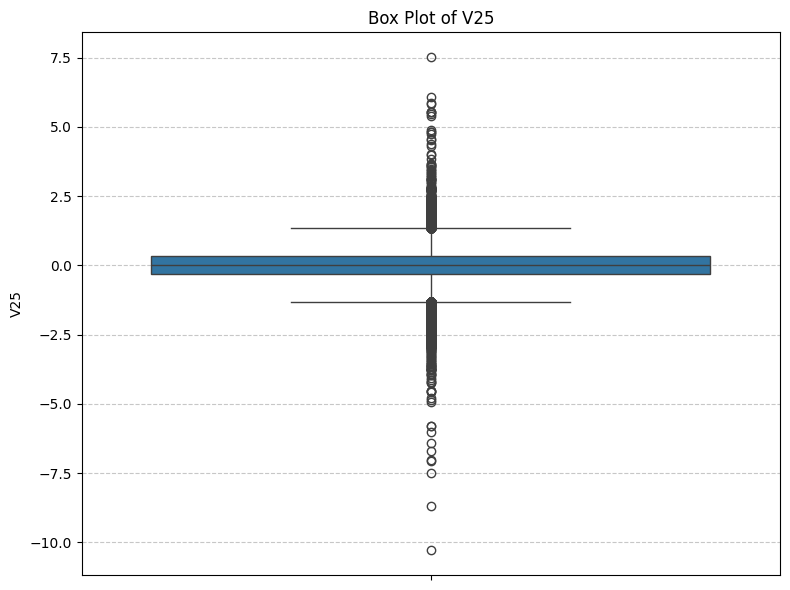

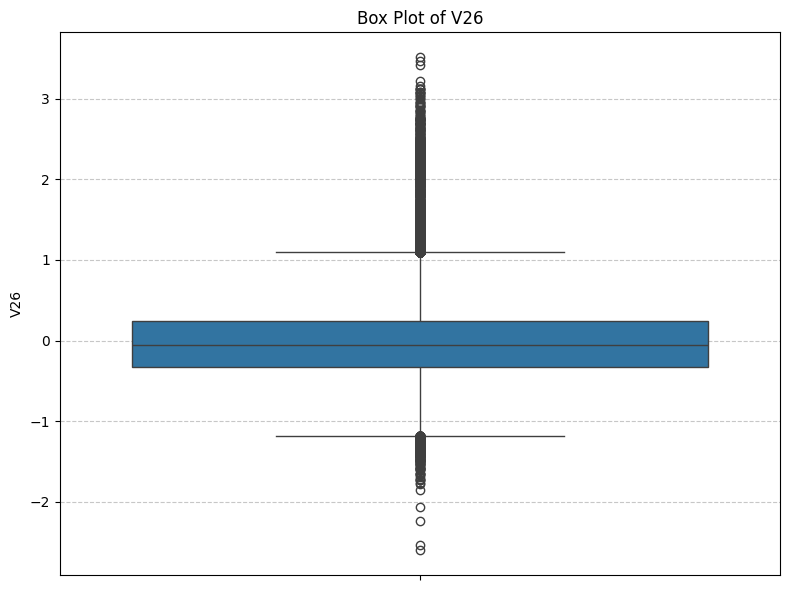

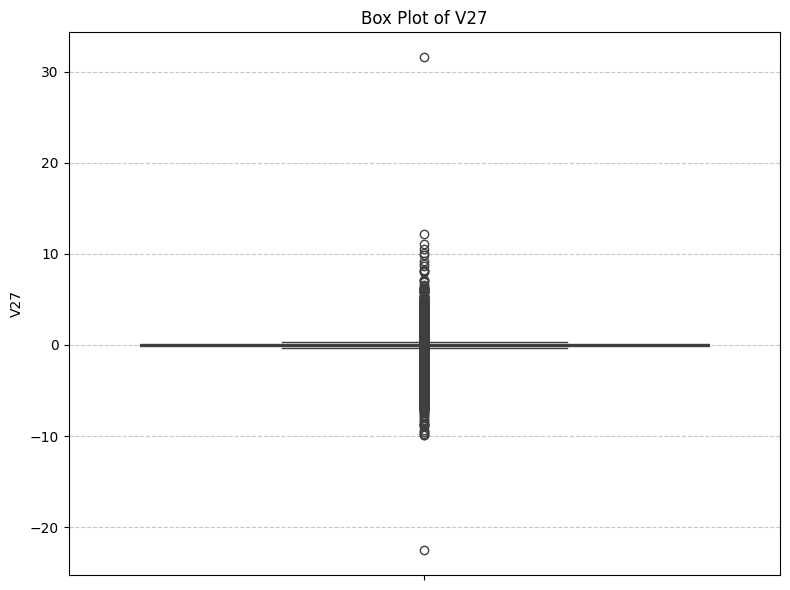

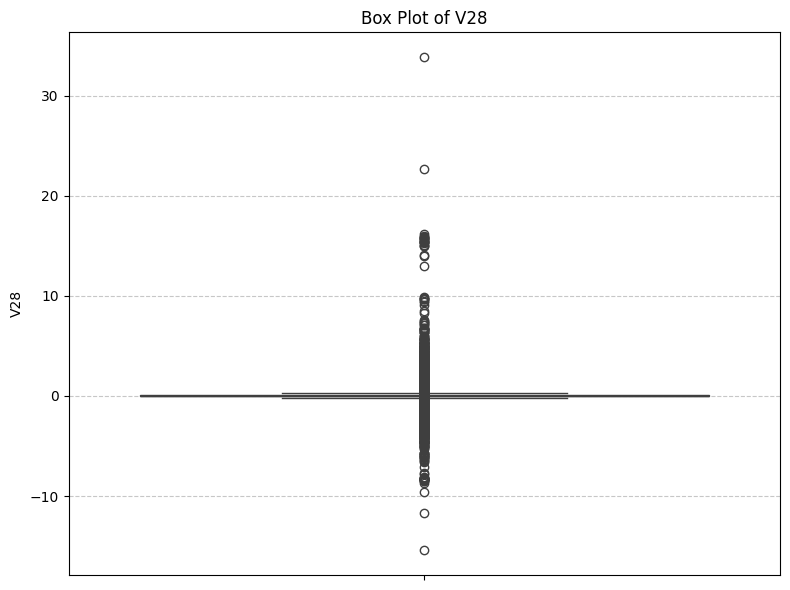

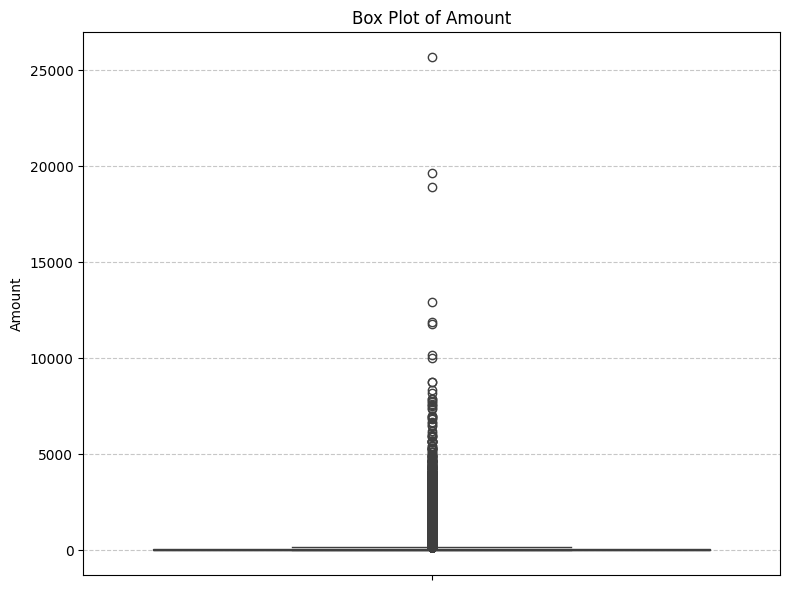

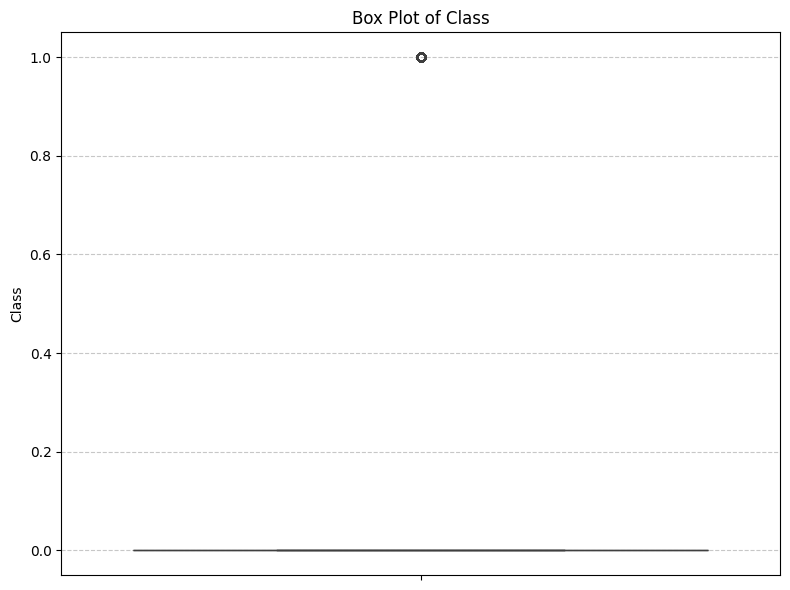

In [24]:
for column in data.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=data[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

#### Analysis of class imbalance

In [30]:
data["Class"].value_counts()
data["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


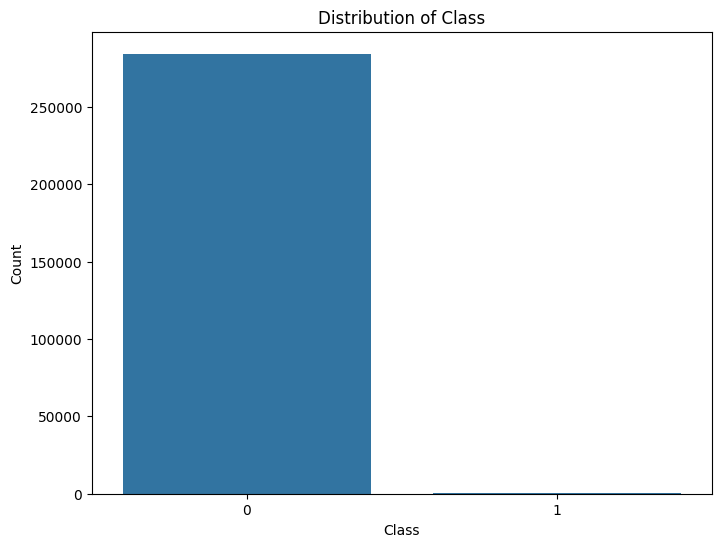

In [32]:
# Bar chart for distribution of class
plt.figure(figsize=(8, 6))
sns.countplot(x="Class", data=data)
plt.title("Distribution of Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Distribution of variables according to fraud

To visualize the distribution of variables according to whether a transaction is fraudulent or not (`Class`), we can use violin plots. These plots are a combination of box plots and kernel density plots, providing a rich view of the distribution of data across different categories. This allows us to compare how the values of each feature are distributed for both legitimate (`Class=0`) and fraudulent (`Class=1`) transactions.

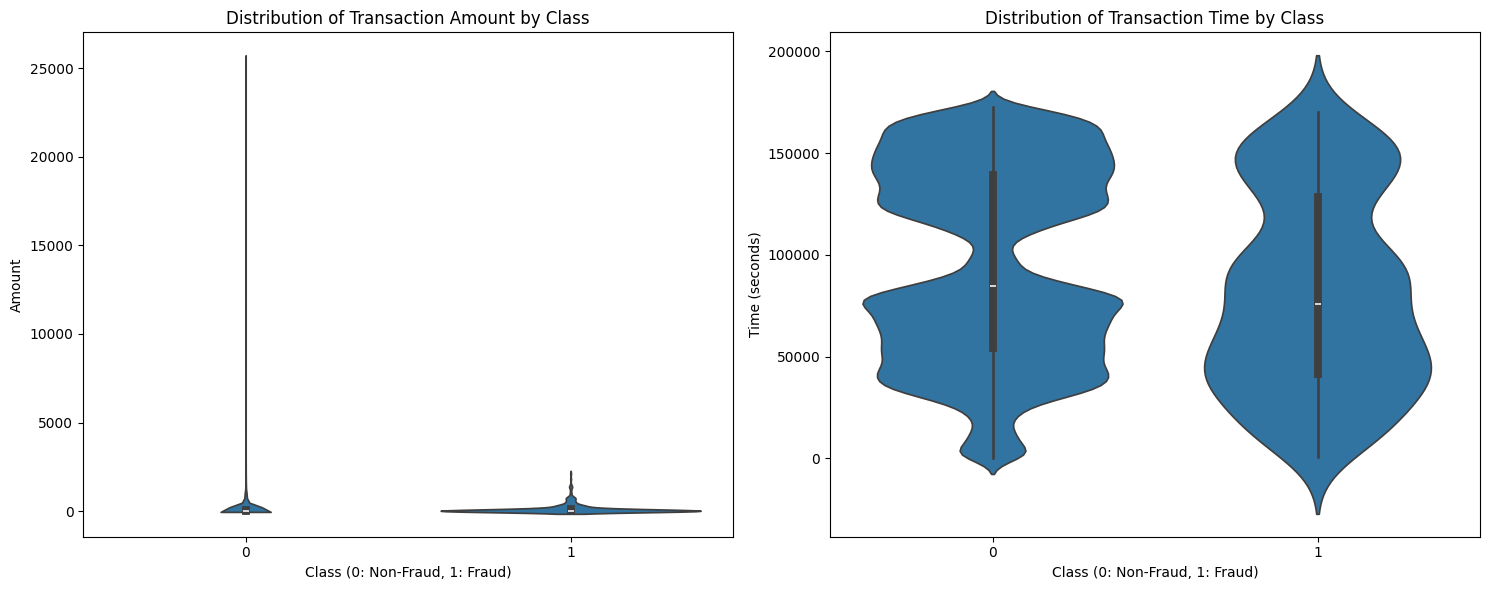

In [33]:
plt.figure(figsize=(15, 6))

# Violin plot for 'Amount' by 'Class'
plt.subplot(1, 2, 1)
sns.violinplot(x='Class', y='Amount', data=data)
plt.title('Distribution of Transaction Amount by Class')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Amount')

# Violin plot for 'Time' by 'Class'
plt.subplot(1, 2, 2)
sns.violinplot(x='Class', y='Time', data=data)
plt.title('Distribution of Transaction Time by Class')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Time (seconds)')

plt.tight_layout()
plt.show()

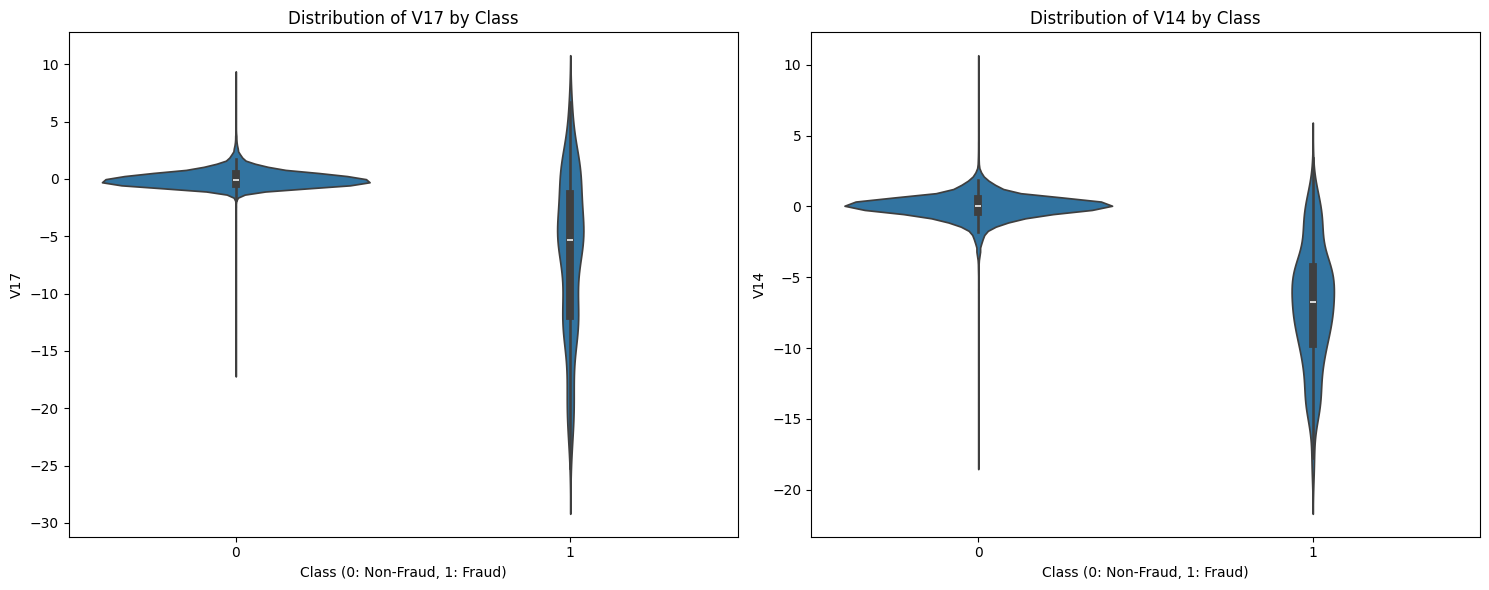

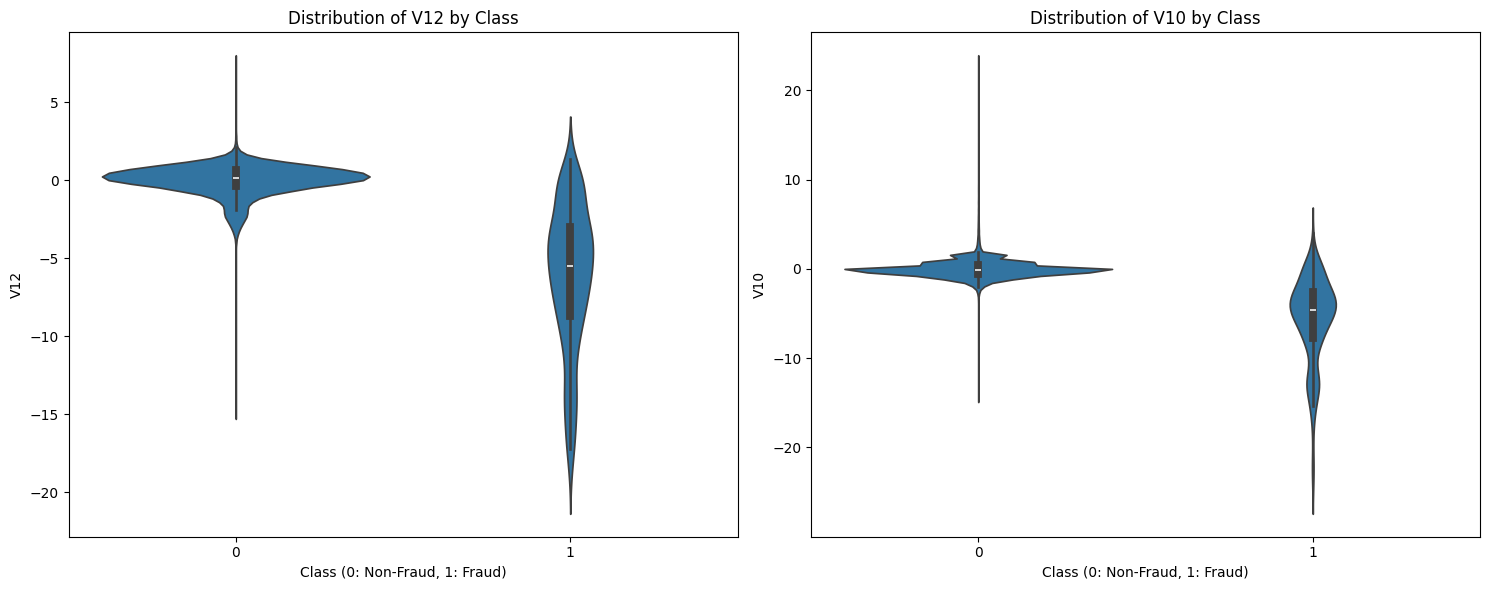

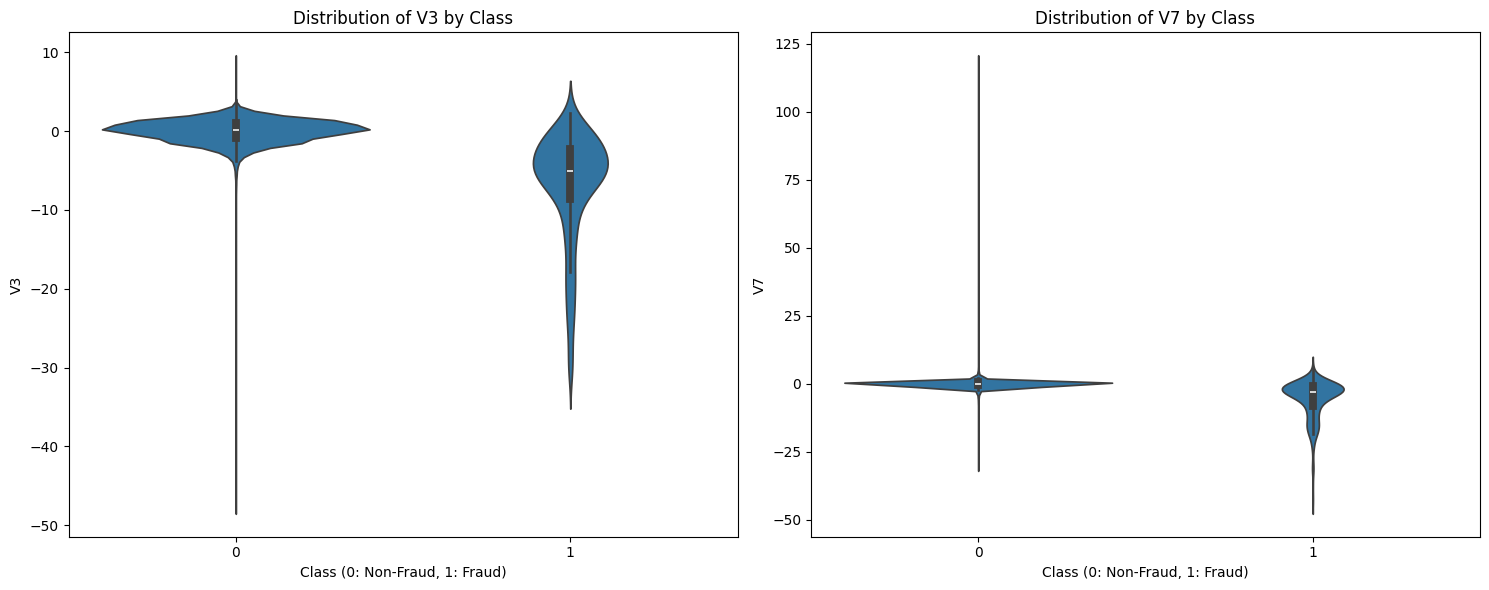

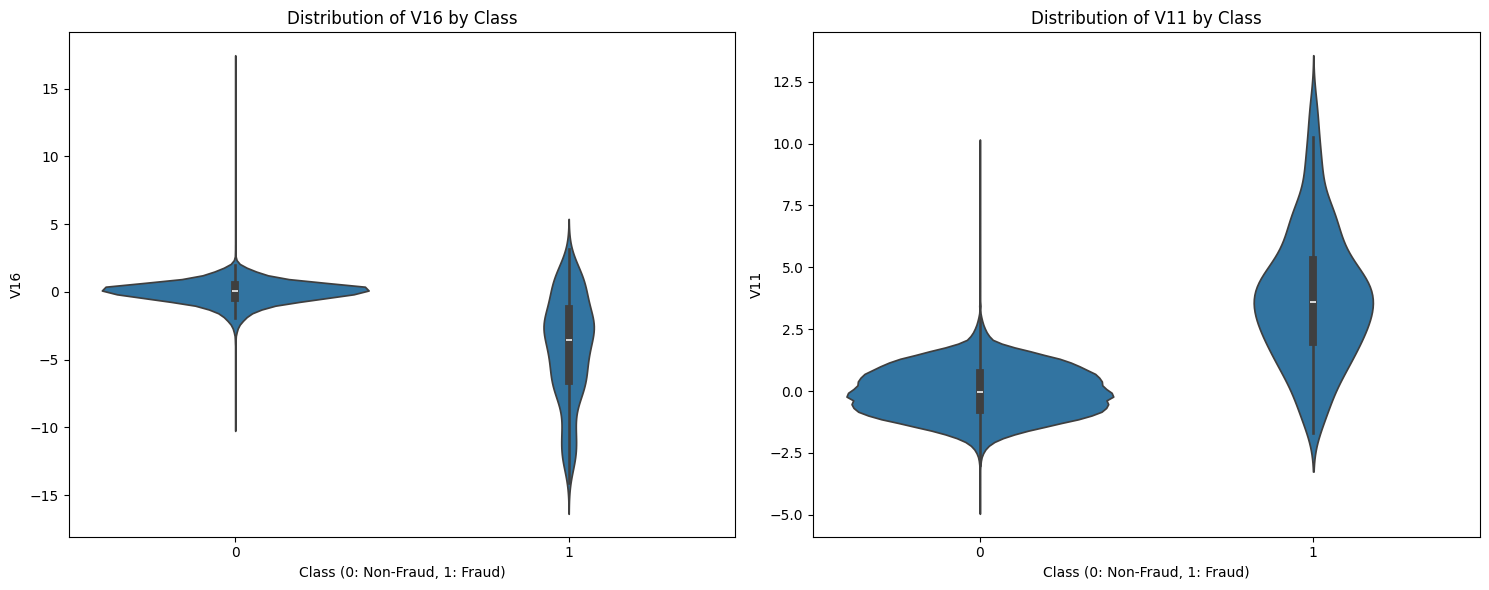

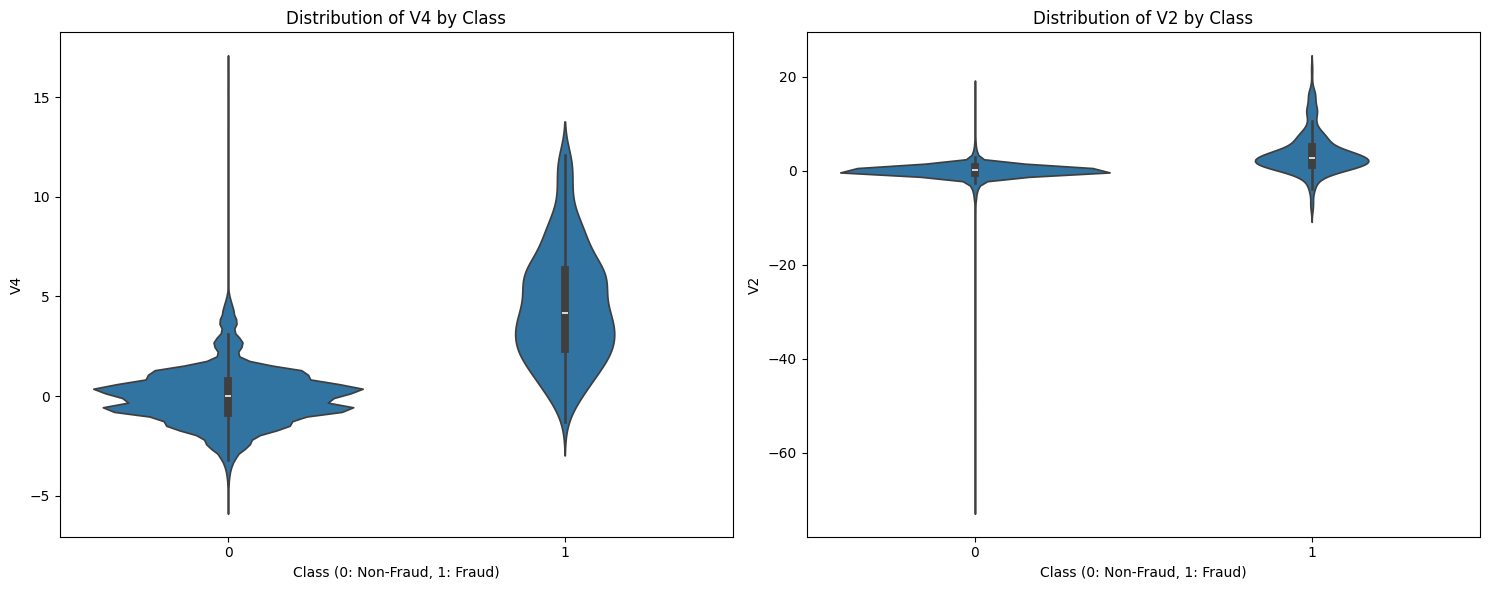

In [34]:
# Let's visualize distributions for some V-features that showed high correlation with 'Class'
high_corr_v_features = ['V17', 'V14', 'V12', 'V10', 'V3', 'V7', 'V16', 'V11', 'V4', 'V2'] # Top absolute correlations

for i, feature in enumerate(high_corr_v_features):
    if i % 2 == 0: # Create a new figure for every two plots
        plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, (i % 2) + 1)
    sns.violinplot(x='Class', y=feature, data=data)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
    plt.ylabel(feature)

    if i % 2 != 0 or i == len(high_corr_v_features) - 1: # Show plot after every two or if it's the last plot
        plt.tight_layout()
        plt.show()

<Axes: xlabel='Time', ylabel='Count'>

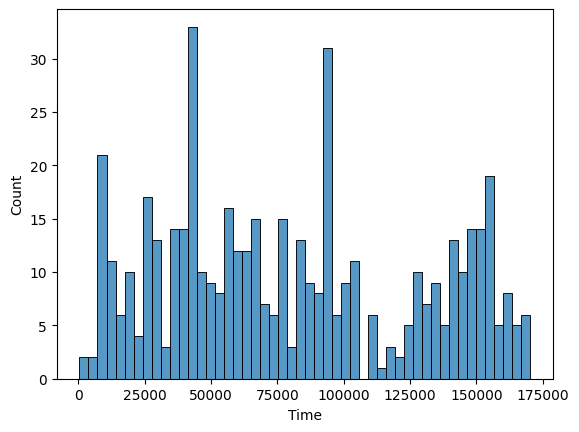

In [35]:
sns.histplot(data[data["Class"]==1]["Time"], bins=50)